In [3]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tifffile
import matplotlib.patches as patches
import os
from scipy.optimize import curve_fit

In [4]:
# path
path_parent = "."
# data_info, which contains tif_name, center_ini, frame_z0
data_info = pd.read_excel(path_parent + os.sep + "data_info.xlsx")

# relate pixel to microns
pixel_to_microns = 110/1000
# z_step (micron)
z_step = 0.1
# colors
colors = ['#E89DA0', '#88CEE6', '#F6C8A8', '#B2D3A4', '#9FBA95', '#E6CECF', '#B696B6', '#80C1C4']


In [5]:
# load extracted info
data_info_extracted = pd.read_csv(path_parent + os.sep + "data_info_extracted_erode_ellipse_more_data.csv")
data_info_extracted_raw = data_info_extracted.copy()

# ---multiple tif check---
# if contains 'flat' in note
tif_index_flat = data_info[data_info['note'].str.contains('flat', case=False)]['tif_name']
# if contains 'tilt' in note
tif_index_tilt = data_info[data_info['note'].str.contains('tilt', case=False)]['tif_name']

# split tif_index_flat into traning and testing; ratio 4:1
# shuffle
tif_index_flat_array = tif_index_flat.to_numpy()
np.random.seed(2024)
np.random.shuffle(tif_index_flat_array)
split_index = int(len(tif_index_flat_array) * 4 / 5)
tif_index_flat_training = tif_index_flat_array[:split_index]
tif_index_flat_testing = tif_index_flat_array[split_index:]

# tif_index_flat_training = tif_index_flat_array


print("training dataset: N = " + str(len(tif_index_flat_training)))

print("testing dataset: N = " + str(len(tif_index_flat_testing)))

print("tilt dataset: N = " + str(len(tif_index_tilt)))

training dataset: N = 60
testing dataset: N = 15
tilt dataset: N = 30


In [6]:
# if ellipse_minor_axis >25, replace with nan
data_info_extracted_raw.loc[data_info_extracted_raw['ellipse_minor_axis'] > 25, ['ellipse_minor_axis', 'ellipse_major_axis', 'ellipse_angle']] = np.nan
# if z_accurate between -0.5, 0.5, and ellipse_minor_axis > 8, replace with nan
data_info_extracted_raw.loc[
    (data_info_extracted_raw['z_accurate'] > -0.5) & 
    (data_info_extracted_raw['z_accurate'] < 0.5) & 
    (data_info_extracted_raw['ellipse_minor_axis'] > 8), 
    ['ellipse_minor_axis', 'ellipse_major_axis', 'ellipse_angle']
] = np.nan
# if z_accurate<-5.5, ellipse_minor_axis< 12, replace with nan
data_info_extracted_raw.loc[
    (data_info_extracted_raw['z_accurate'] < -5.5) & 
    (data_info_extracted_raw['ellipse_minor_axis'] < 12), 
    ['ellipse_minor_axis', 'ellipse_major_axis', 'ellipse_angle']
] = np.nan
# remove dupliacted z_accurate for each unique tif_name
data_info_extracted_raw = data_info_extracted_raw.drop_duplicates(subset=['tif_name', 'z_accurate'], keep='first')

In [7]:
data_info_extracted = data_info_extracted_raw[data_info_extracted_raw['tif_name'].isin(tif_index_flat_training)]
# calculate mean and std of minor axis
data_info_summary = pd.DataFrame(columns=['minor_axis_mean', 'minor_axis_std', 'minor_axis_sem', 'z_accurate', 'N'])
for z_accurate in data_info_extracted['z_accurate'].unique():
    data_info_z = data_info_extracted[data_info_extracted['z_accurate'] == z_accurate]
    # get all minor_axis value
    minor_axis_all = data_info_z['ellipse_minor_axis'].to_numpy() * pixel_to_microns
    # remove nan
    minor_axis_all = minor_axis_all[~np.isnan(minor_axis_all)]
    # keep middle 80%
    minor_axis_all = np.sort(minor_axis_all)
    minor_axis_all = minor_axis_all[int(minor_axis_all.shape[0] * 0.1):int(minor_axis_all.shape[0] * 0.9)]
    # calculate mean and std
    minor_axis_mean = np.mean(minor_axis_all)
    minor_axis_std = np.std(minor_axis_all)
    minor_axis_sem = minor_axis_std / np.sqrt(minor_axis_all.shape[0])
    # minor_axis_mean = np.mean(data_info_z['ellipse_minor_axis']) * pixel_to_microns
    # minor_axis_std = np.std(data_info_z['ellipse_minor_axis']) * pixel_to_microns
    # minor_axis_sem = minor_axis_std / np.sqrt(data_info_z.shape[0])
    N = data_info_z.shape[0]
    data_info_summary_new = pd.DataFrame({'minor_axis_mean': [minor_axis_mean], 'minor_axis_std': [minor_axis_std], 'minor_axis_sem': [minor_axis_sem], 'z_accurate': [z_accurate], 'N': [N]})
    data_info_summary = pd.concat([data_info_summary, data_info_summary_new], axis=0)
# smooth
data_info_summary['minor_axis_mean'] = data_info_summary['minor_axis_mean'].rolling(window=10, min_periods=3).mean()
# save
data_info_summary_training = data_info_summary.copy()

c:\ProgramData\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\ProgramData\anaconda3\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\ProgramData\anaconda3\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\ProgramData\anaconda3\lib\site-packages\numpy\core\_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\ProgramData\anaconda3\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


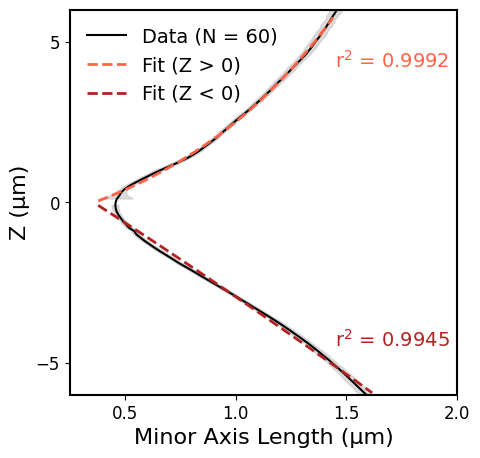

In [8]:
# set fitting range
fit_range = [0, 6] # write the half > 0
pad_for_plot = 0

color_data = "#000000"
color_sem = "#BBBBBB"
color_upper_fit = "#FF6347" 
color_lower_fit = "#B22222" 

data_info_summary = data_info_summary_training
# plot with sem
plt.figure(figsize=(5, 5))
plt.plot(data_info_summary['minor_axis_mean'], data_info_summary['z_accurate'], color=color_data, label='Data (N = ' + str(data_info_summary['N'].max()) + ')')
# fill 99% confidence interval
plt.fill_betweenx(data_info_summary['z_accurate'], data_info_summary['minor_axis_mean']-2.576*data_info_summary['minor_axis_sem'], data_info_summary['minor_axis_mean']+2.576*data_info_summary['minor_axis_sem'], color=color_sem, alpha=0.5)
#  label 
plt.xlabel('Minor Axis Length (µm)')
plt.ylabel('Z (µm)')
# limits
plt.xlim([0.25, 2])
plt.ylim([-fit_range[1]-pad_for_plot, fit_range[1]+pad_for_plot])

# add fitting, exponential
def func(x, a, b, c):
    return a * np.exp(b * x) + c
# brihgt: z = 0-fit_range
data_info_summary_bright = data_info_summary[(data_info_summary['z_accurate'] > fit_range[0]) & (data_info_summary['z_accurate'] <= fit_range[1])]
popt, pcov = curve_fit(func, data_info_summary_bright['minor_axis_mean'], data_info_summary_bright['z_accurate'], p0=[1, 1, 1], maxfev=10000)
fit_bright = pd.DataFrame({'fit_x': np.linspace(0, 2.5, 100), 'fit_y': func(np.linspace(0, 2.5, 100), *popt)})
fit_bright = fit_bright[(fit_bright['fit_y'] > fit_range[0]) & (fit_bright['fit_y'] <= fit_range[1])]
plt.plot(fit_bright['fit_x'], fit_bright['fit_y'], color=color_upper_fit, linestyle='--', linewidth=2, label='Fit (Z > 0)')
# calculate r squared
residuals = data_info_summary_bright['z_accurate'] - func(data_info_summary_bright['minor_axis_mean'], *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((data_info_summary_bright['z_accurate']-np.mean(data_info_summary_bright['z_accurate']))**2)
r_squared = 1 - (ss_res / ss_tot)
plt.text(1.45, 4.2, 'r$^2$ = ' + str(round(r_squared, 4)), fontsize=12, color=color_upper_fit)
# save
popt_bright, pcov_bright, r_squared_bright = popt, pcov, r_squared
# dark: z = fit_range-0
data_info_summary_dark = data_info_summary[(data_info_summary['z_accurate'] >= -fit_range[1]) & (data_info_summary['z_accurate'] <= -fit_range[0])]
popt, pcov = curve_fit(func, data_info_summary_dark['minor_axis_mean'], data_info_summary_dark['z_accurate'], p0=[1, 1, 1], maxfev=10000)
fit_dark = pd.DataFrame({'fit_x': np.linspace(0, 2.5, 100), 'fit_y': func(np.linspace(0, 2.5, 100), *popt)})
fit_dark = fit_dark[(fit_dark['fit_y'] >= -fit_range[1]) & (fit_dark['fit_y'] <= -fit_range[0])]
plt.plot(fit_dark['fit_x'], fit_dark['fit_y'], color=color_lower_fit, linestyle='--', linewidth=2, label='Fit (Z < 0)')
# calculate r squared
residuals = data_info_summary_dark['z_accurate'] - func(data_info_summary_dark['minor_axis_mean'], *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((data_info_summary_dark['z_accurate']-np.mean(data_info_summary_dark['z_accurate']))**2)
r_squared = 1 - (ss_res / ss_tot)
plt.text(1.45, -4.5, 'r$^2$ = ' + str(round(r_squared, 4)), fontsize=12, color=color_lower_fit)
# save
popt_dark, pcov_dark, r_squared_dark = popt, pcov, r_squared

# legend
plt.legend(frameon=False, loc='upper left', fontsize=14)

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=12)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=4)
ax.locator_params(axis='x', nbins=6)

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('3D_library_fitting(99percent_CI).png', format='png', dpi=900, transparent=True, bbox_inches='tight')

In [9]:
data_info_extracted = data_info_extracted_raw[data_info_extracted_raw['tif_name'].isin(tif_index_flat_training)]
# remove data with z_accurate >= 9 or z_accurate <= -9
data_info_extracted = data_info_extracted[(data_info_extracted['z_accurate'] < 9) & (data_info_extracted['z_accurate'] > -9)]
# smooth minor_axis based on tif_name
data_info_extracted['ellipse_minor_axis'] = data_info_extracted['ellipse_minor_axis'].rolling(window=10, min_periods=3).mean()
# calculate mean and std of minor axis
data_info_summary = pd.DataFrame(columns=['minor_axis_mean', 'minor_axis_std', 'minor_axis_sem', 'z_accurate', 'N', 'z_fit_mean', 'z_fit_std', 'z_fit_sem', 'z_reading_error_mean', 'z_reading_error_std', 'z_reading_error_sem'])
for z_accurate in data_info_extracted['z_accurate'].unique():
    data_info_z = data_info_extracted[data_info_extracted['z_accurate'] == z_accurate]
     # get all minor_axis value
    minor_axis_all = data_info_z['ellipse_minor_axis'].to_numpy() * pixel_to_microns
    # remove nan
    minor_axis_all = minor_axis_all[~np.isnan(minor_axis_all)]
    # keep middle 80%
    minor_axis_all = np.sort(minor_axis_all)
    minor_axis_all = minor_axis_all[int(minor_axis_all.shape[0] * 0.1):int(minor_axis_all.shape[0] * 0.9)]
    # calculate mean and std
    minor_axis_mean = np.mean(minor_axis_all)
    minor_axis_std = np.std(minor_axis_all)
    minor_axis_sem = minor_axis_std / np.sqrt(minor_axis_all.shape[0])
    # minor_axis_mean = np.mean(data_info_z['ellipse_minor_axis']) * pixel_to_microns
    # minor_axis_std = np.std(data_info_z['ellipse_minor_axis']) * pixel_to_microns
    # minor_axis_sem = minor_axis_std / np.sqrt(data_info_z.shape[0])
    N = data_info_z.shape[0]
    # fit if z_accurate > 0, bright, else dark
    if z_accurate > 0:
        popt, pcov = popt_bright, pcov_bright
    else:
        popt, pcov = popt_dark, pcov_dark
    # if minor_axis_mean <
    z_fit_mean = np.mean(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt))
    z_fit_std = np.std(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt))
    z_fit_sem = z_fit_std / np.sqrt(data_info_z.shape[0])
    z_reading_error_mean = np.mean(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt)-z_accurate)
    z_reading_error_std = np.std(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt)-z_accurate)
    z_reading_error_sem = z_reading_error_std / np.sqrt(data_info_z.shape[0])
    data_info_summary_new = pd.DataFrame({'minor_axis_mean': [minor_axis_mean], 'minor_axis_std': [minor_axis_std], 'minor_axis_sem': [minor_axis_sem], 'z_accurate': [z_accurate], 'N': [N], 'z_fit_mean': [z_fit_mean], 'z_fit_std': [z_fit_std], 'z_fit_sem': [z_fit_sem], 'z_reading_error_mean': [z_reading_error_mean], 'z_reading_error_std': [z_reading_error_std], 'z_reading_error_sem': [z_reading_error_sem]})
    data_info_summary = pd.concat([data_info_summary, data_info_summary_new], axis=0)
# smooth
# data_info_summary['minor_axis_mean'] = data_info_summary['minor_axis_mean'].rolling(window=3, min_periods=1).mean()
# save
data_info_summary_training_post = data_info_summary.copy()

In [10]:
data_info_extracted = data_info_extracted_raw[data_info_extracted_raw['tif_name'].isin(tif_index_flat_testing)]
# remove data with z_accurate >= 9 or z_accurate <= -9
data_info_extracted = data_info_extracted[(data_info_extracted['z_accurate'] < 9) & (data_info_extracted['z_accurate'] > -9)]
# smooth minor_axis based on tif_name
data_info_extracted['ellipse_minor_axis'] = data_info_extracted['ellipse_minor_axis'].rolling(window=10, min_periods=3).mean()
# calculate mean and std of minor axis
data_info_summary = pd.DataFrame(columns=['minor_axis_mean', 'minor_axis_std', 'minor_axis_sem', 'z_accurate', 'N', 'z_fit_mean', 'z_fit_std', 'z_fit_sem', 'z_reading_error_mean', 'z_reading_error_std', 'z_reading_error_sem'])
for z_accurate in data_info_extracted['z_accurate'].unique():
    data_info_z = data_info_extracted[data_info_extracted['z_accurate'] == z_accurate]
    # get all minor_axis value
    minor_axis_all = data_info_z['ellipse_minor_axis'].to_numpy() * pixel_to_microns
    # remove nan
    minor_axis_all = minor_axis_all[~np.isnan(minor_axis_all)]
    # keep middle 80%
    minor_axis_all = np.sort(minor_axis_all)
    minor_axis_all = minor_axis_all[int(minor_axis_all.shape[0] * 0.1):int(minor_axis_all.shape[0] * 0.9)]
    # calculate mean and std
    minor_axis_mean = np.mean(minor_axis_all)
    minor_axis_std = np.std(minor_axis_all)
    minor_axis_sem = minor_axis_std / np.sqrt(minor_axis_all.shape[0])
    # minor_axis_mean = np.mean(data_info_z['ellipse_minor_axis']) * pixel_to_microns
    # minor_axis_std = np.std(data_info_z['ellipse_minor_axis']) * pixel_to_microns
    # minor_axis_sem = minor_axis_std / np.sqrt(data_info_z.shape[0])
    N = data_info_z.shape[0]
    # fit if z_accurate > 0, bright, else dark
    if z_accurate > 0:
        popt, pcov = popt_bright, pcov_bright
    else:
        popt, pcov = popt_dark, pcov_dark
    z_fit_mean = np.mean(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt))
    z_fit_std = np.std(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt))
    z_fit_sem = z_fit_std / np.sqrt(data_info_z.shape[0])
    z_reading_error_mean = np.mean(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt)-z_accurate)
    z_reading_error_std = np.std(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt)-z_accurate)
    z_reading_error_sem = z_reading_error_std / np.sqrt(data_info_z.shape[0])
    data_info_summary_new = pd.DataFrame({'minor_axis_mean': [minor_axis_mean], 'minor_axis_std': [minor_axis_std], 'minor_axis_sem': [minor_axis_sem], 'z_accurate': [z_accurate], 'N': [N], 'z_fit_mean': [z_fit_mean], 'z_fit_std': [z_fit_std], 'z_fit_sem': [z_fit_sem], 'z_reading_error_mean': [z_reading_error_mean], 'z_reading_error_std': [z_reading_error_std], 'z_reading_error_sem': [z_reading_error_sem]})
    data_info_summary = pd.concat([data_info_summary, data_info_summary_new], axis=0)
# smooth
# data_info_summary['minor_axis_mean'] = data_info_summary['minor_axis_mean'].rolling(window=3, min_periods=1).mean()
# save
data_info_summary_testing = data_info_summary.copy()

data_info_extracted = data_info_extracted_raw[data_info_extracted_raw['tif_name'].isin(tif_index_tilt)]
# remove data with z_accurate >= 9 or z_accurate <= -9
data_info_extracted = data_info_extracted[(data_info_extracted['z_accurate'] < 9) & (data_info_extracted['z_accurate'] > -9)]
# smooth minor_axis based on tif_name
data_info_extracted['ellipse_minor_axis'] = data_info_extracted['ellipse_minor_axis'].rolling(window=10, min_periods=3).mean()
# calculate mean and std of minor axis
data_info_summary = pd.DataFrame(columns=['minor_axis_mean', 'minor_axis_std', 'minor_axis_sem', 'z_accurate', 'N', 'z_fit_mean', 'z_fit_std', 'z_fit_sem', 'z_reading_error_mean', 'z_reading_error_std', 'z_reading_error_sem'])
for z_accurate in data_info_extracted['z_accurate'].unique():
    data_info_z = data_info_extracted[data_info_extracted['z_accurate'] == z_accurate]
    # get all minor_axis value
    minor_axis_all = data_info_z['ellipse_minor_axis'].to_numpy() * pixel_to_microns
    # remove nan
    minor_axis_all = minor_axis_all[~np.isnan(minor_axis_all)]
    # keep middle 80%
    minor_axis_all = np.sort(minor_axis_all)
    minor_axis_all = minor_axis_all[int(minor_axis_all.shape[0] * 0.1):int(minor_axis_all.shape[0] * 0.9)]
    # calculate mean and std
    minor_axis_mean = np.mean(minor_axis_all)
    minor_axis_std = np.std(minor_axis_all)
    minor_axis_sem = minor_axis_std / np.sqrt(minor_axis_all.shape[0])
    # minor_axis_mean = np.mean(data_info_z['ellipse_minor_axis']) * pixel_to_microns
    # minor_axis_std = np.std(data_info_z['ellipse_minor_axis']) * pixel_to_microns
    # minor_axis_sem = minor_axis_std / np.sqrt(data_info_z.shape[0])
    N = data_info_z.shape[0]
    # fit if z_accurate > 0, bright, else dark
    if z_accurate > 0:
        popt, pcov = popt_bright, pcov_bright
    else:
        popt, pcov = popt_dark, pcov_dark
    z_fit_mean = np.mean(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt))
    z_fit_std = np.std(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt))
    z_fit_sem = z_fit_std / np.sqrt(data_info_z.shape[0])
    z_reading_error_mean = np.mean(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt)-z_accurate)
    z_reading_error_std = np.std(func(data_info_z['ellipse_minor_axis'] * pixel_to_microns, *popt)-z_accurate)
    z_reading_error_sem = z_reading_error_std / np.sqrt(data_info_z.shape[0])
    data_info_summary_new = pd.DataFrame({'minor_axis_mean': [minor_axis_mean], 'minor_axis_std': [minor_axis_std], 'minor_axis_sem': [minor_axis_sem], 'z_accurate': [z_accurate], 'N': [N], 'z_fit_mean': [z_fit_mean], 'z_fit_std': [z_fit_std], 'z_fit_sem': [z_fit_sem], 'z_reading_error_mean': [z_reading_error_mean], 'z_reading_error_std': [z_reading_error_std], 'z_reading_error_sem': [z_reading_error_sem]})
    data_info_summary = pd.concat([data_info_summary, data_info_summary_new], axis=0)
# smooth
# data_info_summary['minor_axis_mean'] = data_info_summary['minor_axis_mean'].rolling(window=3, min_periods=1).mean()
# save
data_info_summary_tilt = data_info_summary.copy()

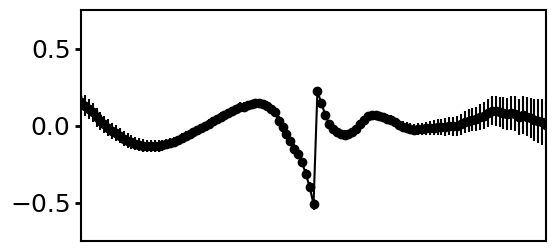

In [11]:
# prepare z_comparison
z_comparison = pd.DataFrame(columns=['z_accurate', 'z_fit', 'delta_z'])

data_info_summary_comparison = data_info_summary_training_post
color = '#000000'
# for data_info_summary
z_comparison['z_accurate'] = data_info_summary_comparison['z_accurate']
z_comparison['delta_z'] = data_info_summary_comparison['z_reading_error_mean']
z_comparison['delta_z_std'] = data_info_summary_comparison['z_reading_error_std']
z_comparison['delta_z_sem'] = data_info_summary_comparison['z_reading_error_sem']

# plot z_comparison
plt.figure(figsize=(6, 3))
# plt.plot(z_comparison['z_accurate'], z_comparison['delta_z'], 'r')
# plot sem
# plt.fill_between(z_comparison['z_accurate'], z_comparison['delta_z']-z_comparison['delta_z_sem'], z_comparison['delta_z']+z_comparison['delta_z_sem'], color='r', alpha=0.5)
# plot dots + line + sem error bar
plt.errorbar(z_comparison['z_accurate'], z_comparison['delta_z'], yerr=z_comparison['delta_z_sem'], fmt='o-', color=color, label='training_post')
plt.xlabel('Accurate Z ($\mu$m)')
plt.ylabel('Prediction Error ($\mu$m)')
# plt.ylim([-1, 1])
plt.ylim([-0.75, 0.75])
plt.xlim([-6, 6])
# plt.title('training dataset')
# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=12)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=4)
ax.locator_params(axis='x', nbins=5)

# hide x y labels
ax.set_xlabel('')
ax.set_ylabel('')
# hide x ticks
ax.set_xticks([])

# make y ticks thicker
ax.yaxis.set_tick_params(width=2, length=4)
# make y tick labels larger
ax.yaxis.set_tick_params(labelsize=18)

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('prediction_error_training.png', format='png', dpi=900, transparent=True, bbox_inches='tight')


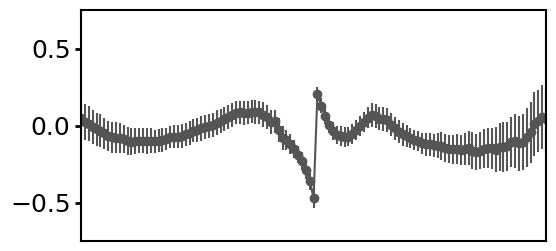

In [12]:
# prepare z_comparison
z_comparison = pd.DataFrame(columns=['z_accurate', 'z_fit', 'delta_z'])

data_info_summary_comparison = data_info_summary_testing
color = '#555555'
# for data_info_summary
z_comparison['z_accurate'] = data_info_summary_comparison['z_accurate']
z_comparison['delta_z'] = data_info_summary_comparison['z_reading_error_mean']
z_comparison['delta_z_std'] = data_info_summary_comparison['z_reading_error_std']
z_comparison['delta_z_sem'] = data_info_summary_comparison['z_reading_error_sem']

# plot z_comparison
plt.figure(figsize=(6, 3))
# plt.plot(z_comparison['z_accurate'], z_comparison['delta_z'], 'r')
# plot sem
# plt.fill_between(z_comparison['z_accurate'], z_comparison['delta_z']-z_comparison['delta_z_sem'], z_comparison['delta_z']+z_comparison['delta_z_sem'], color='r', alpha=0.5)
# plot dots + line + sem error bar
plt.errorbar(z_comparison['z_accurate'], z_comparison['delta_z'], yerr=z_comparison['delta_z_sem'], fmt='o-', color=color, label='testing')
plt.xlabel('Accurate Z ($\mu$m)')
plt.ylabel('Prediction Error ($\mu$m)')
# plt.ylim([-1, 1])
plt.ylim([-0.75, 0.75])
plt.xlim([-6, 6])
# plt.title('testing dataset')
# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=12)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=4)
ax.locator_params(axis='x', nbins=5)

# hide x y labels
ax.set_xlabel('')
ax.set_ylabel('')
# hide x ticks
ax.set_xticks([])

# make y ticks thicker
ax.yaxis.set_tick_params(width=2, length=4)
# make y tick labels larger
ax.yaxis.set_tick_params(labelsize=18)

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('prediction_error_testing.png', format='png', dpi=900, transparent=True, bbox_inches='tight')

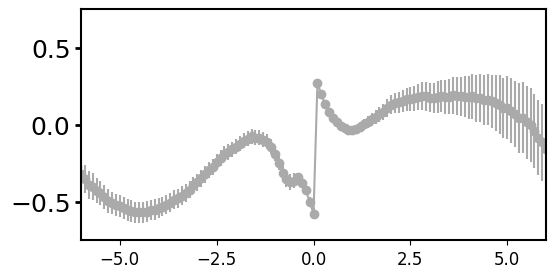

In [13]:
# prepare z_comparison
z_comparison = pd.DataFrame(columns=['z_accurate', 'z_fit', 'delta_z'])

data_info_summary_comparison = data_info_summary_tilt
color = '#AAAAAA'
# for data_info_summary
z_comparison['z_accurate'] = data_info_summary_comparison['z_accurate']
z_comparison['delta_z'] = data_info_summary_comparison['z_reading_error_mean']
z_comparison['delta_z_std'] = data_info_summary_comparison['z_reading_error_std']
z_comparison['delta_z_sem'] = data_info_summary_comparison['z_reading_error_sem']

# plot z_comparison
plt.figure(figsize=(6, 3))
# plt.plot(z_comparison['z_accurate'], z_comparison['delta_z'], 'r')
# plot sem
# plt.fill_between(z_comparison['z_accurate'], z_comparison['delta_z']-z_comparison['delta_z_sem'], z_comparison['delta_z']+z_comparison['delta_z_sem'], color='r', alpha=0.5)
# plot dots + line + sem error bar
plt.errorbar(z_comparison['z_accurate'], z_comparison['delta_z'], yerr=z_comparison['delta_z_sem'], fmt='o-', color=color, label='tilt')
plt.xlabel('Accurate Z ($\mu$m)')
plt.ylabel('Prediction Error ($\mu$m)')
# plt.ylim([-1, 1])
plt.ylim([-0.75, 0.75])
plt.xlim([-6, 6])
# plt.title('tilt dataset')
# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=12)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=4)
ax.locator_params(axis='x', nbins=5)

# hide x y labels
ax.set_xlabel('')
ax.set_ylabel('')
# # hide x ticks
# ax.set_xticks([])

# make y ticks thicker
ax.yaxis.set_tick_params(width=2, length=4)
# make y tick labels larger
ax.yaxis.set_tick_params(labelsize=18)
# make x tick labels larger
# ax.xaxis.set_tick_params(labelsize=18)

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('prediction_error_tilt.png', format='png', dpi=900, transparent=True, bbox_inches='tight')

In [14]:
# save popt, pcov, r_squared to csv
parameters_summary = pd.DataFrame(columns=['popt_bright', 'pcov_bright', 'r_squared_bright', 'popt_dark', 'pcov_dark', 'r_squared_dark'])
parameters_summary_new = pd.DataFrame({'popt_bright': [popt_bright], 'pcov_bright': [pcov_bright], 'r_squared_bright': [r_squared_bright], 'popt_dark': [popt_dark], 'pcov_dark': [pcov_dark], 'r_squared_dark': [r_squared_dark]})
parameters_summary = pd.concat([parameters_summary, parameters_summary_new], axis=0)
# parameters_summary.to_csv(path_parent + os.sep + "parameters_summary.csv", index=False)

